# Correlation Analysis

##### In this notebook the results of the analysis all come together. The mentioned elements of the tourism system, Tourist Pressure, Threshold and Phenomenon, are translated into the results of previously performed data analysis. The tourist pressure consists of the Google Maps Data. The perception of the phenomen consists of data from the municipality of Amsterdam. The threshold, which could tell us what influences this perception, consists of the elements in the urban environment.

In [1]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
wijk = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/INDELING_WIJK.csv", delimiter = ";")
wijk = wijk[wijk["Stadsdeel"].isin(["West", "Oost", "Centrum", "Zuid"])]
wijk = wijk[["Wijk", "Stadsdeel"]]

### Tourist Pressure

In [3]:
#TOURIST PRESSURE
prs = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/pressure_tourism.csv", index_col=0)


In [4]:
prs

,Buurt,Wijk,place_id,reviews 2024,rev_prc,name,Business,Day,Hour,Busyness,Dayname,Weekday,pressure
0,Felix Meritisbuurt,Grachtengordel-West,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Nooch,Tuesday,0,0,Tuesday,NaN,0.000000
1,Felix Meritisbuurt,Grachtengordel-West,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Nooch,Tuesday,1,0,Tuesday,NaN,0.000000
2,Felix Meritisbuurt,Grachtengordel-West,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Nooch,Tuesday,2,0,Tuesday,NaN,0.000000
3,Felix Meritisbuurt,Grachtengordel-West,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Nooch,Tuesday,3,0,Tuesday,NaN,0.000000
4,Felix Meritisbuurt,Grachtengordel-West,ChIJFTdsYMMJxkcRryoUM7EyJY0,133.0,0.007290,Nooch,Nooch,Tuesday,4,0,Tuesday,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640851,Hoofdcentrum-Zuidoost,Amstel III/Bullewijk,ChIJX_h0D_IIxkcR8kPHza8R7kw,1693.0,0.092803,AFAS Live,AFAS Live,Monday,19,52,Monday,6.0,4.825741
1640852,Hoofdcentrum-Zuidoost,Amstel III/Bullewijk,ChIJX_h0D_IIxkcR8kPHza8R7kw,1693.0,0.092803,AFAS Live,AFAS Live,Monday,20,30,Monday,6.0,2.784082
1640853,Hoofdcentrum-Zuidoost,Amstel III/Bullewijk,ChIJX_h0D_IIxkcR8kPHza8R7kw,1693.0,0.092803,AFAS Live,AFAS Live,Monday,21,30,Monday,6.0,2.784082
1640854,Hoofdcentrum-Zuidoost,Amstel III/Bullewijk,ChIJX_h0D_IIxkcR8kPHza8R7kw,1693.0,0.092803,AFAS Live,AFAS Live,Monday,22,32,Monday,6.0,2.969687


In [6]:
prs = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/new_pressure_time.csv", index_col=0)

In [6]:
#### MAKING DF THAT SHOWS PRESSURE PER PLACE
#test = prs.groupby("Wijk")["pressure"].sum().reset_index()
#test = idc.merge(test, left_on = "wijken", right_on = "Wijk").corr()
#test.plot("Totaalscore toeristische druk", "pressure", kind = "scatter")

# load places data to give coords to pressure data
places = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/test_times.csv", index_col=0)[["place_id", "name", "geometry"]]
# Group pressure on place and name, to get pressure of place (overall)
plc_prs = prs.groupby(["place_id", "name", "datetime"])["pressure"].sum().reset_index()

#merge two dataframes
plc_prs = plc_prs.merge(places, on = ["place_id", "name"], how = "left")
plc_prs["datetime"] = pd.to_datetime(plc_prs["datetime"])
plc_prs["Hour"] = plc_prs["datetime"].dt.hour
plc_prs["Dayname"] = plc_prs["datetime"].dt.day_name()

#plc_prs.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/place_pressure.csv")


##Total pressure of place
#plc_prs = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/place_pressure.csv", index_col = 0)

In [7]:
plc_prs

,place_id,name,datetime,pressure,geometry,Hour,Dayname
0,ChIJ--17ntTjxUcR7UDCPpIqMWE,Enfes Restaurant,2024-01-01 00:00:00,0.000000,POINT (4.810651 52.353958999999996),0,Monday
1,ChIJ--17ntTjxUcR7UDCPpIqMWE,Enfes Restaurant,2024-01-01 01:00:00,0.000000,POINT (4.810651 52.353958999999996),1,Monday
2,ChIJ--17ntTjxUcR7UDCPpIqMWE,Enfes Restaurant,2024-01-01 02:00:00,0.000000,POINT (4.810651 52.353958999999996),2,Monday
3,ChIJ--17ntTjxUcR7UDCPpIqMWE,Enfes Restaurant,2024-01-01 03:00:00,0.000000,POINT (4.810651 52.353958999999996),3,Monday
4,ChIJ--17ntTjxUcR7UDCPpIqMWE,Enfes Restaurant,2024-01-01 04:00:00,0.000000,POINT (4.810651 52.353958999999996),4,Monday
...,...,...,...,...,...,...,...
541291,ChIJzx7F4r8JxkcRpWLr0JLTA8s,Coffeeshop Family First,2024-01-07 19:00:00,1.209998,POINT (4.8953932 52.3669187),19,Sunday
541292,ChIJzx7F4r8JxkcRpWLr0JLTA8s,Coffeeshop Family First,2024-01-07 20:00:00,1.132434,POINT (4.8953932 52.3669187),20,Sunday
541293,ChIJzx7F4r8JxkcRpWLr0JLTA8s,Coffeeshop Family First,2024-01-07 21:00:00,1.334101,POINT (4.8953932 52.3669187),21,Sunday
541294,ChIJzx7F4r8JxkcRpWLr0JLTA8s,Coffeeshop Family First,2024-01-07 22:00:00,1.256537,POINT (4.8953932 52.3669187),22,Sunday


In [7]:
prs_wijk = prs.groupby(["Wijk", "datetime"])["pressure"].sum().reset_index()

In [9]:
#prs_wijk = prs_wijk.pivot(columns = ["Dayname", "Hour"], index = "Wijk", values = "pressure").reset_index()

In [ ]:
category = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/Google/P2 Data/places_categorised.csv", index_col = 0)[["place_id", "category"]]

In [17]:
prs_cat = category.merge(prs, on = "place_id", how = "inner")
prs_cat["datetime"] = pd.to_datetime(prs_cat["datetime"])
prs_cat["Hour"] = prs_cat["datetime"].dt.hour
prs_cat["Dayname"] = prs_cat["datetime"].dt.day_name()
# Optional: sort by datetime if needed
prs_cat = prs_cat.sort_values('datetime')
prs_cat = prs_cat.groupby(["category","Hour"])["pressure"].sum().reset_index()

In [34]:
prs_cat

,category,Dayname,Hour,pressure
0,Dining & Cafes,Friday,0,0.119717
1,Dining & Cafes,Friday,1,0.000000
2,Dining & Cafes,Friday,2,0.000000
3,Dining & Cafes,Friday,3,0.000000
4,Dining & Cafes,Friday,4,0.000000
...,...,...,...,...
499,Shopping,Wednesday,19,3.539659
500,Shopping,Wednesday,20,3.021488
501,Shopping,Wednesday,21,1.554898
502,Shopping,Wednesday,22,1.252754


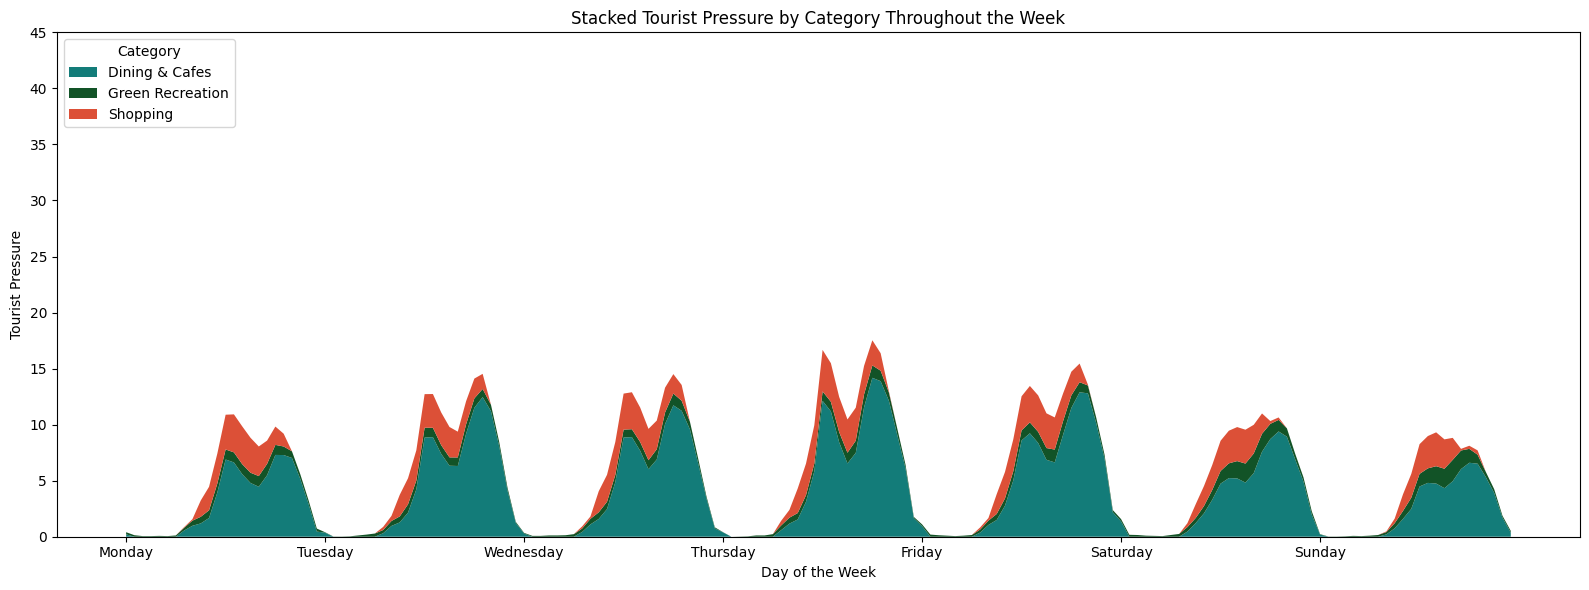

In [50]:
import matplotlib.pyplot as plt

# Define custom colors
custom_colors = {
    'Dining & Cafes': '#137c79',
    'Green Recreation': '#125327',
    'Cannabisshop': '#1ba03e',
    'Entertainment & Nightlife': '#392669',
    'Activities': '#97191a',
    'Shopping': '#dc5037',
    'Conference': '#2e2e2f',
    'Cultural & Historic': '#084a90',
    'Event venue': '#692266'
}

# Create a pivot table with MultiIndex (Dayname, Hour)
df_pivot = prs_cat.pivot_table(
    index=['Dayname', 'Hour'],
    columns='category',
    values='pressure',
    aggfunc='sum'  # in case there are still duplicates
)

# Optional: reindex to order days properly
ordered_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_pivot = df_pivot.reindex(ordered_days, level='Dayname')

# Flatten the MultiIndex for plotting (e.g., convert to a long datetime string)
df_pivot.index = [f"{day} {hour:02d}:00" for day, hour in df_pivot.index]

# Get colors in column order
colors = [custom_colors[cat] for cat in df_pivot.columns]

# Plot
plt.figure(figsize=(16, 6))
plt.stackplot(df_pivot.index, df_pivot.T, labels=df_pivot.columns, colors=colors)

# Get x-tick positions for each day
unique_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ticks = [i * 24 for i in range(len(unique_days))]  # 24 hours per day
tick_labels = unique_days

# Apply x-axis formatting
plt.xticks(ticks=ticks, labels=tick_labels, rotation=0, fontsize=10)

# Labels and title
plt.legend(loc='upper left', title="Category")
plt.xlabel("Day of the Week")
plt.ylabel("Tourist Pressure")
plt.title("Stacked Tourist Pressure by Category Throughout the Week")
plt.ylim(0,45)

# Remove grid
plt.grid(visible=False)

plt.tight_layout()
plt.show()


In [20]:
bijlmer_arena = ["Hoofdcentrum-Zuidoost"]
zuidas = ["Beatrixpark", "Zuidas-Noord", "RAI", "Zuidas-Zuid", "Vivaldi", "De Klenckebuurt"]
sloterdijk = ["Sloterdijk Stationskwartier"]

In [44]:
prs_bijlmer = category.merge(prs, on = "place_id", how = "inner")
prs_cat = prs_bijlmer[prs_bijlmer["Buurt"].isin(bijlmer_arena)]
prs_cat["datetime"] = pd.to_datetime(prs_cat["datetime"])
prs_cat["Hour"] = prs_cat["datetime"].dt.hour
prs_cat["Dayname"] = prs_cat["datetime"].dt.day_name()
# Optional: sort by datetime if needed
prs_cat = prs_cat.sort_values('datetime')
prs_cat = prs_cat.groupby(["category", "Dayname", "Hour"])["pressure"].sum().reset_index()

C:\Users\isamu\AppData\Local\Temp\ipykernel_15136\3949879704.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prs_cat["datetime"] = pd.to_datetime(prs_cat["datetime"])
C:\Users\isamu\AppData\Local\Temp\ipykernel_15136\3949879704.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prs_cat["Hour"] = prs_cat["datetime"].dt.hour
C:\Users\isamu\AppData\Local\Temp\ipykernel_15136\3949879704.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [47]:
prs_sloterdijk = category.merge(prs, on = "place_id", how = "inner")
prs_cat = prs_sloterdijk[prs_sloterdijk["Buurt"].isin(sloterdijk)]
prs_cat["datetime"] = pd.to_datetime(prs_cat["datetime"])
prs_cat["Hour"] = prs_cat["datetime"].dt.hour
prs_cat["Dayname"] = prs_cat["datetime"].dt.day_name()
# Optional: sort by datetime if needed
prs_cat = prs_cat.sort_values('datetime')
prs_cat = prs_cat.groupby(["category", "Dayname", "Hour"])["pressure"].sum().reset_index()

C:\Users\isamu\AppData\Local\Temp\ipykernel_15136\1821904399.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prs_cat["datetime"] = pd.to_datetime(prs_cat["datetime"])
C:\Users\isamu\AppData\Local\Temp\ipykernel_15136\1821904399.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prs_cat["Hour"] = prs_cat["datetime"].dt.hour
C:\Users\isamu\AppData\Local\Temp\ipykernel_15136\1821904399.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [49]:
prs_zuid = category.merge(prs, on = "place_id", how = "inner")
prs_cat = prs_zuid[prs_zuid["Buurt"].isin(zuidas)]
prs_cat["datetime"] = pd.to_datetime(prs_cat["datetime"])
prs_cat["Hour"] = prs_cat["datetime"].dt.hour
prs_cat["Dayname"] = prs_cat["datetime"].dt.day_name()
# Optional: sort by datetime if needed
prs_cat = prs_cat.sort_values('datetime')
prs_cat = prs_cat.groupby(["category", "Dayname", "Hour"])["pressure"].sum().reset_index()

C:\Users\isamu\AppData\Local\Temp\ipykernel_15136\2305553817.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prs_cat["datetime"] = pd.to_datetime(prs_cat["datetime"])
C:\Users\isamu\AppData\Local\Temp\ipykernel_15136\2305553817.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prs_cat["Hour"] = prs_cat["datetime"].dt.hour
C:\Users\isamu\AppData\Local\Temp\ipykernel_15136\2305553817.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [29]:
# Pivot the data so each category becomes a column
df_pivot = prs_cat.pivot(index='Hour', columns='category', values='pressure')

# Sort by datetime to ensure correct order
df_pivot = df_pivot.sort_index()

# Plot stacked area chart
plt.figure(figsize=(14, 6))
plt.stackplot(df_pivot.index, df_pivot.T, labels=df_pivot.columns)

# Formatting
plt.legend(loc='upper left', title="Category")
plt.xlabel("Time")
plt.ylabel("Pressure")
plt.ylim(0, 200)
plt.title("Total Stacked Tourist Pressure by Category Over the Day")
#plt.grid()
plt.show()

ValueError: Index contains duplicate entries, cannot reshape

### THRESHOLD - Morphological elements

In [13]:
#SPACE SYNTAX (NEED TO ADD PER WIJK)
pst = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/space syntax/wijken_ac.csv")

In [14]:
#SPACE
pedestrian_space = gpd.read_file("C:/Users/isamu/OneDrive/THESIS/DATA/pedestrian_space_area.gpkg")
private_space = gpd.read_file("C:/Users/isamu/OneDrive/THESIS/DATA/Amsterdam/neighbourhood_erf.gpkg")
open_space = gpd.read_file("C:/Users/isamu/OneDrive/THESIS/DATA/Amsterdam/neighbourhood_private_space.gpkg")
#green_space = pd.read_csv("C:\Users\isamu\Downloads/HOOFDGROENSTRUCTUUR.csv", delimiter = ";")
#trees  = gpd.read_file("C:/Users/isamu/OneDrive/ENVIRONMENTAL STUDIES/Final project/trees per neigh 5g.gpkg")

In [15]:
#PRIVATE SPACE
private_space = private_space.drop(columns = "eindRegistratie")
private_space["private space area"] = private_space["geometry"].area
private_space_value = private_space.groupby("Wijk")["private space area"].sum().reset_index()

#PEDESTRIAN SPACE
pedestrian_space["pedestrian space area"] = pedestrian_space["geometry"].area
pedestrian_space_value = pedestrian_space.groupby("Wijk")["pedestrian space area"].sum().reset_index()

#OPEN SPACE
open_space["open space area"] = open_space["geometry"].area
open_space_value = open_space.groupby("Wijk")["open space area"].sum().reset_index()

In [16]:
wijk_threshold = private_space_value.merge(pedestrian_space_value, on = "Wijk", how = "inner")
wijk_threshold = wijk_threshold.merge(open_space_value, on = "Wijk", how = "inner")
wijk_threshold

,Wijk,private space area,pedestrian space area,open space area
0,Aetsveld/Oostelijke Vechtoever,671742.750945,59957.560325,9.241071e+05
1,Amstel III/Bullewijk,704199.544198,283910.439569,1.450310e+06
2,Amsterdamse Poort e.o.,115205.697531,237769.045384,3.520048e+05
3,Apollobuurt,217557.444596,170546.875655,4.550267e+05
4,Banne Buiksloot,156020.293475,195869.074156,4.176916e+05
...,...,...,...,...
105,Westlandgracht,117155.862442,201769.892367,3.281025e+05
106,Willemspark,117734.873134,123690.289369,2.544108e+05
107,Zeeburgereiland/Bovendiep,204684.421673,109209.154271,3.504212e+05
108,Zuid Pijp,95281.128277,67018.569564,2.138860e+05


### Phenomenon of Overtourism

In [2]:
#TOURISM RATINGS PER WIJK
tourism = pd.read_excel("C:/Users/isamu/OneDrive/THESIS/toerisme scores.xlsx", sheet_name = 0)
tourism = tourism[tourism["jaar"] == 2023]
tourism = tourism[["gebiednaam", "VTOERIST_P"]]
tourism = tourism.rename(columns = {"gebiednaam":"Wijk", "VTOERIST_P":"% tourism nuisance"})

In [3]:
#TOURISM RATINGS OTHER VARIABLES
idc = pd.read_excel("C:/Users/isamu/OneDrive/THESIS/toerisme scores.xlsx", sheet_name = 1)
idc[["code", "wijken"]] = idc["wijken"].str.split(' ', n=1, expand = True)
idc = idc.rename(columns = {"wijken":"Wijk"})

In [4]:
wijk_phenom = tourism.merge(idc, on = "Wijk", how = "left")
wijk_phenom = wijk_phenom[["Wijk", "% tourism nuisance", "Overlast door dronken mensen op straat", "Oordeel winkelaanbod dagelijkse boodschappen", "Overlast door vervuiling", 
                           "Onveiligheids-belevingsindex", "Sociale cohesie", "Totaalscore bezoekersgerelateerde leefbaarheid"]]

In [5]:
wijk = pd.read_csv("C:/Users/isamu/OneDrive/THESIS/DATA/INDELING_WIJK.csv", delimiter = ";")
lens = wijk[["Wijk", "WKT_LNG_LAT"]]
asi = wijk_phenom.merge(lens, on = "Wijk", how = "left")
#asi.to_csv("C:/Users/isamu/OneDrive/THESIS/DATA/overtourism_scores_wijk.csv")
asi

,Wijk,% tourism nuisance,Overlast door dronken mensen op straat,Oordeel winkelaanbod dagelijkse boodschappen,Overlast door vervuiling,Onveiligheids-belevingsindex,Sociale cohesie,Totaalscore bezoekersgerelateerde leefbaarheid,WKT_LNG_LAT
0,Haarlemmerbuurt,18.0,15.5,7.8,5.8,89.2,6.2,17.0,"POLYGON((4.881667 52.38418,4.882537 52.383924,..."
1,Jordaan,24.0,10.2,8.2,5.6,87.4,6.2,15.0,"POLYGON((4.875487 52.37341,4.875432 52.373235,..."
2,Grachtengordel-West,43.0,12.7,8.1,5.1,90.7,6.0,13.0,"POLYGON((4.886206 52.378089,4.883155 52.374752..."
3,Burgwallen-Nieuwe Zijde,47.0,35.9,7.5,4.3,128.9,5.1,9.0,"POLYGON((4.891315 52.376324,4.891181 52.376192..."
4,Burgwallen-Oude Zijde,49.0,55.2,6.8,3.4,142.9,5.6,7.0,"POLYGON((4.899692 52.377303,4.899141 52.376971..."
...,...,...,...,...,...,...,...,...,...
106,Holendrecht,0.0,5.9,7.4,5.7,130.3,6.1,16.0,"POLYGON((4.955402 52.302497,4.955749 52.302098..."
107,Nellestein,1.0,0.0,4.0,7.0,96.4,5.8,22.0,"POLYGON((4.97142 52.307997,4.976269 52.302687,..."
108,Reigersbos,1.0,10.0,7.9,5.7,119.7,5.6,14.0,"POLYGON((4.961747 52.295381,4.963191 52.293881..."
109,Gein,0.0,2.7,7.2,6.8,131.9,6.2,19.0,"POLYGON((4.979897 52.301516,4.979911 52.300579..."


### Correlation

In [10]:
df = tourism.merge(prs_wijk, on = "Wijk", how = "right")

In [11]:
prs_wijk

,Wijk,Dayname,Hour,pressure
0,Aetsveld/Oostelijke Vechtoever,Friday,0,0.000000
1,Aetsveld/Oostelijke Vechtoever,Friday,1,0.000000
2,Aetsveld/Oostelijke Vechtoever,Friday,2,0.000000
3,Aetsveld/Oostelijke Vechtoever,Friday,3,0.000000
4,Aetsveld/Oostelijke Vechtoever,Friday,4,0.000000
...,...,...,...,...
17731,Zuidas,Wednesday,19,52.249411
17732,Zuidas,Wednesday,20,39.597544
17733,Zuidas,Wednesday,21,28.366387
17734,Zuidas,Wednesday,22,4.449213


In [15]:
#df = wijk.merge(df, left_on = "Wijk", right_on = "gebiednaam", how = "left")

In [17]:
# Step 1: Join dataframes
combined_df = prs_wijk.merge(wijk_phenom, on='Wijk').merge(wijk_threshold, on='Wijk')

# Step 2: Define a function to calculate correlation per moment
def calculate_correlations(df, morphology_cols, nuisance_cols, time_cols=['Dayname', 'Hour']):
    results = []

    # Group by time slots
    grouped = df.groupby(time_cols)
    
    for time, group in grouped:
        for nuisance in nuisance_cols:
            # Correlation between pressure and nuisance
            corr_pressure_nuisance = group['pressure'].corr(group[nuisance])

            # Correlation between morphological elements and nuisance
            morph_corrs = {f'corr_{morph}_{nuisance}': group[morph].corr(group[nuisance]) for morph in morphology_cols}

            results.append({
                'Dayname': time[0],
                'Hour': time[1],
                'nuisance_metric': nuisance,
                'corr_pressure_nuisance': corr_pressure_nuisance,
                **morph_corrs
            })
            
    return pd.DataFrame(results)

# Define your columns clearly
morphology_cols = ['private space area', 'pedestrian space area', 'open space area']
nuisance_cols = ['% tourism nuisance', 
                 'Overlast door dronken mensen op straat', 
                 'Oordeel winkelaanbod dagelijkse boodschappen', 
                 'Overlast door vervuiling', 
                 'Onveiligheids-belevingsindex', 
                 'Sociale cohesie', 
                 'Totaalscore bezoekersgerelateerde leefbaarheid']

# Run correlation calculations
correlation_df = calculate_correlations(combined_df, morphology_cols, nuisance_cols)

# Inspect the results
correlation_df


,Dayname,Hour,nuisance_metric,corr_pressure_nuisance,corr_private space area_% tourism nuisance,corr_pedestrian space area_% tourism nuisance,corr_open space area_% tourism nuisance,corr_private space area_Overlast door dronken mensen op straat,corr_pedestrian space area_Overlast door dronken mensen op straat,corr_open space area_Overlast door dronken mensen op straat,...,corr_open space area_Overlast door vervuiling,corr_private space area_Onveiligheids-belevingsindex,corr_pedestrian space area_Onveiligheids-belevingsindex,corr_open space area_Onveiligheids-belevingsindex,corr_private space area_Sociale cohesie,corr_pedestrian space area_Sociale cohesie,corr_open space area_Sociale cohesie,corr_private space area_Totaalscore bezoekersgerelateerde leefbaarheid,corr_pedestrian space area_Totaalscore bezoekersgerelateerde leefbaarheid,corr_open space area_Totaalscore bezoekersgerelateerde leefbaarheid
0,Friday,0,% tourism nuisance,0.832710,-0.174402,-0.16681,-0.036475,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Friday,0,Overlast door dronken mensen op straat,0.783582,NaN,NaN,NaN,-0.304926,-0.181374,-0.228007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Friday,0,Oordeel winkelaanbod dagelijkse boodschappen,0.092943,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Friday,0,Overlast door vervuiling,-0.361479,NaN,NaN,NaN,NaN,NaN,NaN,...,0.305589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Friday,0,Onveiligheids-belevingsindex,0.041961,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.226842,0.239454,-0.212108,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,Wednesday,23,Oordeel winkelaanbod dagelijkse boodschappen,0.076883,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1172,Wednesday,23,Overlast door vervuiling,-0.401644,NaN,NaN,NaN,NaN,NaN,NaN,...,0.305589,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1173,Wednesday,23,Onveiligheids-belevingsindex,0.078627,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.226842,0.239454,-0.212108,NaN,NaN,NaN,NaN,NaN,NaN
1174,Wednesday,23,Sociale cohesie,-0.186940,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.419559,-0.225159,0.279399,NaN,NaN,NaN


In [21]:
# Define the start of the week (e.g., Monday of any arbitrary week)
day_to_date = {
    'Monday': '2024-01-01',
    'Tuesday': '2024-01-02',
    'Wednesday': '2024-01-03',
    'Thursday': '2024-01-04',
    'Friday': '2024-01-05',
    'Saturday': '2024-01-06',
    'Sunday': '2024-01-07',
}

# Create datetime by combining date + hour
correlation_df['datetime'] = pd.to_datetime(correlation_df['Dayname'].map(day_to_date)) + pd.to_timedelta(correlation_df['Hour'], unit='h')

# Optional: sort by datetime if needed
correlation_df = correlation_df.sort_values('datetime')

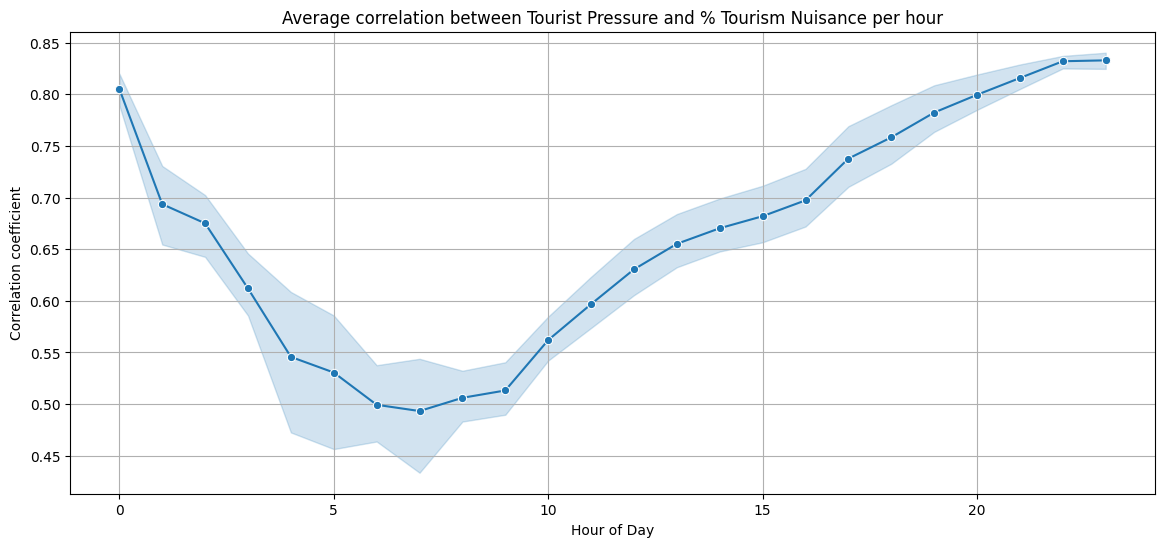

In [81]:
# Example: visualize correlation between pressure and % tourism nuisance throughout a typical Friday
friday_data = correlation_df[
    #(correlation_df['Dayname'] == 'Tuesday') & 
    (correlation_df['nuisance_metric'] == '% tourism nuisance')
]

plt.figure(figsize=(14, 6))
sns.lineplot(data=friday_data, x='Hour', y='corr_pressure_nuisance', marker='o')
plt.title('Average correlation between Tourist Pressure and % Tourism Nuisance per hour')
plt.xlabel('Hour of Day')
plt.ylabel('Correlation coefficient')
plt.grid()
plt.show()

In [84]:
import statsmodels.formula.api as smf

# Base model (without morphology)
base_model = smf.ols(formula='Q("% tourism nuisance") ~ avg_pressure', data=df).fit()

# Moderation model (with interaction terms)
moderation_model = smf.ols(
    formula='Q("% tourism nuisance") ~ avg_pressure + \
             Q("open space area") + Q("private space area") + Q("pedestrian space area") + \
             avg_pressure_open_space + avg_pressure_private_space + avg_pressure_pedestrian_space',
    data=df).fit()

# Compare model summaries
print("Base model:\n", base_model.summary())
print("\nModeration model:\n", moderation_model.summary())

# Model comparison (ANOVA)
anova_results = sm.stats.anova_lm(base_model, moderation_model)
print("\nANOVA comparison:\n", anova_results)


Base model:
                                OLS Regression Results                              
Dep. Variable:     Q("% tourism nuisance")   R-squared:                       0.540
Model:                                 OLS   Adj. R-squared:                  0.535
Method:                      Least Squares   F-statistic:                     106.9
Date:                     Thu, 27 Mar 2025   Prob (F-statistic):           5.05e-17
Time:                             13:56:12   Log-Likelihood:                -311.83
No. Observations:                       93   AIC:                             627.7
Df Residuals:                           91   BIC:                             632.7
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [85]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# === STEP 1: Load and Merge Data ===
# Assuming wijk_phenom, prs_wijk, wijk_threshold are already loaded.

# Aggregate tourist pressure metrics per neighborhood
agg_pressure = prs_wijk.groupby('Wijk').agg(
    avg_pressure=('pressure', 'mean'),
    max_pressure=('pressure', 'max'),
    median_pressure=('pressure', 'median'),
    total_weekly_pressure=('pressure', 'sum')
).reset_index()

# Combine datasets into a single DataFrame
df = wijk_phenom.merge(agg_pressure, on='Wijk').merge(wijk_threshold, on='Wijk')

# === STEP 2: Create Interaction Terms ===
df['avg_pressure_open_space'] = df['avg_pressure'] * df['open space area']
df['avg_pressure_private_space'] = df['avg_pressure'] * df['private space area']
df['avg_pressure_pedestrian_space'] = df['avg_pressure'] * df['pedestrian space area']

# === STEP 3: Run Regression Analyses ===

# Base Model: Nuisance ~ Avg. Pressure
base_model = smf.ols(
    formula='Q("% tourism nuisance") ~ avg_pressure',
    data=df
).fit()

# Moderation Model: Nuisance ~ Pressure + Morphology + Interaction Terms
moderation_model = smf.ols(
    formula='Q("% tourism nuisance") ~ avg_pressure + \
             Q("open space area") + Q("private space area") + Q("pedestrian space area") + \
             avg_pressure_open_space + avg_pressure_private_space + avg_pressure_pedestrian_space',
    data=df
).fit()

# === STEP 4: Output Results ===
print("=== Base Model Summary ===")
print(base_model.summary())

print("\n=== Moderation Model Summary ===")
print(moderation_model.summary())

# === STEP 5: Model Comparison (ANOVA Test) ===
anova_results = sm.stats.anova_lm(base_model, moderation_model)
print("\n=== ANOVA Comparison ===")
print(anova_results)


=== Base Model Summary ===
                               OLS Regression Results                              
Dep. Variable:     Q("% tourism nuisance")   R-squared:                       0.540
Model:                                 OLS   Adj. R-squared:                  0.535
Method:                      Least Squares   F-statistic:                     106.9
Date:                     Thu, 27 Mar 2025   Prob (F-statistic):           5.05e-17
Time:                             14:00:45   Log-Likelihood:                -311.83
No. Observations:                       93   AIC:                             627.7
Df Residuals:                           91   BIC:                             632.7
Df Model:                                1                                         
Covariance Type:                 nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

In [93]:
# instead of: from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler


In [96]:
dfscaler = StandardScaler()

# List of columns to standardize
cols_to_scale = ['avg_pressure', 'open space area', 'private space area', 'pedestrian space area']

# Create standardized columns (prefixed with z_)
df[[f'z_{col}' for col in cols_to_scale]] = dfscaler.fit_transform(df[cols_to_scale])

In [97]:
# New standardized interaction terms
df['z_pressure_open_space'] = df['z_avg_pressure'] * df['z_open space area']
df['z_pressure_private_space'] = df['z_avg_pressure'] * df['z_private space area']
df['z_pressure_pedestrian_space'] = df['z_avg_pressure'] * df['z_pedestrian space area']


In [99]:
standardized_model = smf.ols(
    formula='Q("% tourism nuisance") ~ z_avg_pressure + \
             Q("z_open space area") + Q("z_private space area") + Q("z_pedestrian space area") + \
             z_pressure_open_space + z_pressure_private_space + z_pressure_pedestrian_space',
    data=df
).fit()

# Display the results
print(standardized_model.summary())



                               OLS Regression Results                              
Dep. Variable:     Q("% tourism nuisance")   R-squared:                       0.796
Model:                                 OLS   Adj. R-squared:                  0.780
Method:                      Least Squares   F-statistic:                     47.47
Date:                     Thu, 27 Mar 2025   Prob (F-statistic):           9.60e-27
Time:                             14:32:20   Log-Likelihood:                -273.96
No. Observations:                       93   AIC:                             563.9
Df Residuals:                           85   BIC:                             584.2
Df Model:                                7                                         
Covariance Type:                 nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------